In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import pickle
import scvi
import matplotlib.pyplot as plt

from cellina import CellinaModel
from utils import set_seed

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [ ]:
set_seed(0)

In [6]:
adata = sc.read(
    f"/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_210.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/210.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [7]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

In [8]:
from cellina._spatial_utils import spatial_neighbors

n_neighbors = 50
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [9]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [10]:
from scipy.sparse import csr_matrix

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X / n_neighbors
# float32
adata.obsm['spatial_x'] = csr_matrix(adata.obsm['spatial_x']).astype(np.float32)

/tmp/ipykernel_3330357/1053621386.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=100)


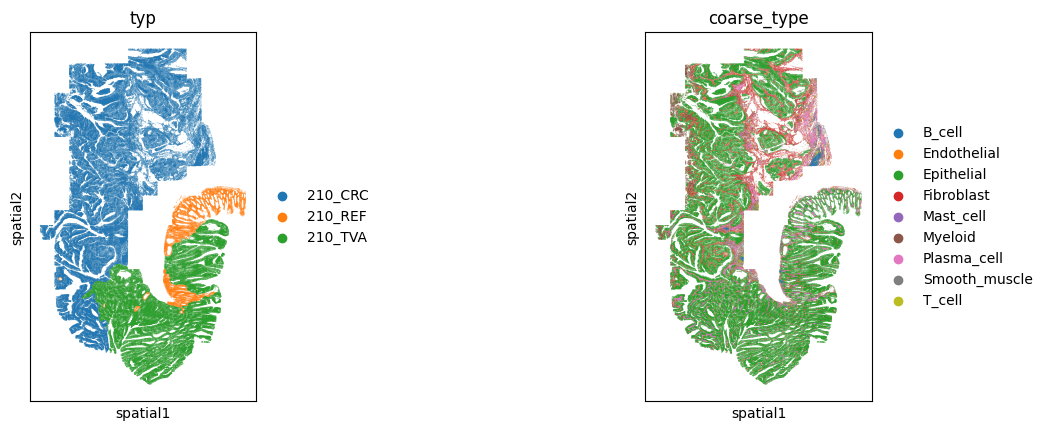

In [11]:
sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=100)

## Data splits

In [12]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    is_non_epi = adata.obs["coarse_type"] != "Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_non_epi)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [13]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [14]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [15]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [18]:
model_args = {
    'adata': adata,
    'n_latent': 64,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'early_stopping_patience': 25,
              'early_stopping_monitor': "validation_loss",
              'enable_checkpointing': True,
              'devices': [1],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              }
plan_kwargs = {
    'lr': 1e-4,
    'normalize_losses': True
    }

In [17]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [19]:
model = CellinaModel(
    **model_args,
    classifier_lambda=1., discriminator_lambda=1., 
)
model.train(
    **train_args,
    plan_kwargs=plan_kwargs
)

model.save(f"{base_path}/trained/crc_210_{split}", overwrite=True)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many 

Epoch 46/100:  46%|████▌     | 46/100 [17:25<20:27, 22.73s/it, v_num=1, train_loss=320]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 320.859. Signaling Trainer to stop.


# Analysis

## Latent visualization

## Latents celltype and niche prediction

## Hotspot

## Pathway enrichment

## Deeplift